In [3]:
pip install pyodbc sqlalchemy pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [32]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-TG851V8\\SQLEXPRESS;"
    "DATABASE=python;"
    "Trusted_Connection=yes;"
)
print("Connected successfully")

Connected successfully


In [33]:
query = "SELECT * FROM sample_dataset"

df = pd.read_sql(query, conn)

df.head()

,emp_ID,Full_Name,AGE,dept_code,salary_USD,yrs_exp,perf_score,TEMP_FLAG,internal_ref,city
0,1001,Grace Brown,61.0,OPS,56745.0,NaN,3.96,True,REF0000,Pune
1,1002,Eva Young,53.0,FIN,61890.0,NaN,1.43,True,REF0001,Mumbai
2,1003,Carol Clark,55.0,IT,50022.0,NaN,2.26,False,REF0002,None
3,1004,Eva Young,49.0,OPS,82579.0,30.0,1.02,True,REF0003,Hyderabad
4,1005,Bob Lee,52.0,None,100316.0,4.0,3.73,True,REF0004,Hyderabad


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   emp_ID        508 non-null    int64  
 1   Full_Name     508 non-null    object 
 2   AGE           447 non-null    float64
 3   dept_code     477 non-null    object 
 4   salary_USD    447 non-null    float64
 5   yrs_exp       448 non-null    float64
 6   perf_score    447 non-null    float64
 7   TEMP_FLAG     508 non-null    bool   
 8   internal_ref  508 non-null    object 
 9   city          478 non-null    object 
dtypes: bool(1), float64(4), int64(1), object(4)
memory usage: 36.3+ KB


In [35]:
df.describe()

,emp_ID,AGE,salary_USD,yrs_exp,perf_score
count,508.000000,447.000000,447.000000,448.000000,447.000000
mean,1253.797244,41.834452,75191.190157,17.435268,3.007562
std,145.698644,11.928952,25939.527660,9.898605,1.179704
min,1001.000000,22.000000,30207.000000,0.000000,1.000000
25%,1127.750000,31.000000,53879.000000,9.000000,1.940000
50%,1254.500000,43.000000,74843.000000,19.000000,3.100000
75%,1381.250000,52.000000,98597.500000,25.000000,4.040000
max,1500.000000,61.000000,119899.000000,34.000000,5.000000


In [37]:
df.columns

Index(['emp_ID', 'Full_Name', 'AGE', 'dept_code', 'salary_USD', 'yrs_exp',
       'perf_score', 'TEMP_FLAG', 'internal_ref', 'city'],
      dtype='object')

In [38]:
df=df.rename(columns={"AGE":"Age","yrs_exp":"Years_Exp", "TEMP_FLAG": "Temp_Flag" , "city" : "City" })

In [39]:
df.columns

Index(['emp_ID', 'Full_Name', 'Age', 'dept_code', 'salary_USD', 'Years_Exp',
       'perf_score', 'Temp_Flag', 'internal_ref', 'City'],
      dtype='object')

In [40]:
df[df.duplicated()]

,emp_ID,Full_Name,Age,dept_code,salary_USD,Years_Exp,perf_score,Temp_Flag,internal_ref,City
500,1450,David Jones,39.0,IT,NaN,27.0,1.52,True,REF0449,Pune
501,1451,Henry Hall,28.0,IT,61750.0,30.0,NaN,True,REF0450,Pune
502,1452,David Brown,31.0,MKT,70461.0,26.0,4.47,True,REF0451,Hyderabad
503,1453,Eva Jones,28.0,None,103800.0,4.0,3.29,True,REF0452,Chennai
504,1454,David Brown,NaN,IT,108222.0,24.0,4.63,False,REF0453,Pune
505,1472,Bob Lee,26.0,OPS,67685.0,20.0,3.70,False,REF0471,Hyderabad
506,1473,Eva Clark,58.0,FIN,103965.0,23.0,4.78,True,REF0472,Mumbai
507,1474,Grace Smith,59.0,FIN,44716.0,33.0,2.08,True,REF0473,Mumbai


In [41]:
df.drop_duplicates(inplace=True)

In [42]:
df[df.duplicated()]

,emp_ID,Full_Name,Age,dept_code,salary_USD,Years_Exp,perf_score,Temp_Flag,internal_ref,City


In [45]:
df = df.drop(columns=['Temp_Flag', 'internal_ref', 'perf_score'])

In [46]:
df

,emp_ID,Full_Name,Age,dept_code,salary_USD,Years_Exp,City
0,1001,Grace Brown,61.0,OPS,56745.0,NaN,Pune
1,1002,Eva Young,53.0,FIN,61890.0,NaN,Mumbai
2,1003,Carol Clark,55.0,IT,50022.0,NaN,None
3,1004,Eva Young,49.0,OPS,82579.0,30.0,Hyderabad
4,1005,Bob Lee,52.0,None,100316.0,4.0,Hyderabad
...,...,...,...,...,...,...,...
495,1496,Frank Smith,25.0,None,65262.0,NaN,Bangalore
496,1497,Frank Smith,NaN,OPS,108213.0,NaN,Mumbai
497,1498,Carol Clark,NaN,HR,NaN,34.0,Mumbai
498,1499,Eva Brown,55.0,OPS,107866.0,32.0,Delhi


In [50]:
df.isnull().sum()

emp_ID         0
Full_Name      0
Age           60
dept_code     30
salary_USD    60
Years_Exp     60
City          30
dtype: int64

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   emp_ID      500 non-null    int64  
 1   Full_Name   500 non-null    object 
 2   Age         440 non-null    float64
 3   dept_code   470 non-null    object 
 4   salary_USD  440 non-null    float64
 5   Years_Exp   440 non-null    float64
 6   City        470 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 31.2+ KB


In [52]:
# For Multiple Variables Data Cleaing / Processing
cols = ['Age', 'salary_USD','Years_Exp' ]
df[cols] = df[cols].fillna(df[cols].mean())

In [53]:
# For Multiple Variables Data Cleaing / Processing
cols = ['dept_code', 'City']
df[cols] = df[cols].fillna(df[cols].mode().iloc[0])

In [54]:
df.isnull().sum()

emp_ID        0
Full_Name     0
Age           0
dept_code     0
salary_USD    0
Years_Exp     0
City          0
dtype: int64

In [55]:
df['City_Avg_Salary'] = df.groupby('City')['salary_USD'].transform('mean')

In [61]:
df['Salary_Band'] = pd.cut(
    df['salary_USD'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

In [62]:
df

,emp_ID,Full_Name,Age,dept_code,salary_USD,Years_Exp,City,City_Avg_Salary,Salary_Band
0,1001,Grace Brown,61.000000,OPS,56745.000,17.327273,Pune,77929.332609,Low
1,1002,Eva Young,53.000000,FIN,61890.000,17.327273,Mumbai,75117.519521,Medium
2,1003,Carol Clark,55.000000,IT,50022.000,17.327273,Delhi,74802.702756,Low
3,1004,Eva Young,49.000000,OPS,82579.000,30.000000,Hyderabad,75303.956875,Medium
4,1005,Bob Lee,52.000000,IT,100316.000,4.000000,Hyderabad,75303.956875,High
...,...,...,...,...,...,...,...,...,...
495,1496,Frank Smith,25.000000,IT,65262.000,17.327273,Bangalore,72045.881471,Medium
496,1497,Frank Smith,41.888636,OPS,108213.000,17.327273,Mumbai,75117.519521,High
497,1498,Carol Clark,41.888636,HR,75113.325,34.000000,Mumbai,75117.519521,Medium
498,1499,Eva Brown,55.000000,OPS,107866.000,32.000000,Delhi,74802.702756,High


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   emp_ID           500 non-null    int64   
 1   Full_Name        500 non-null    object  
 2   Age              500 non-null    float64 
 3   dept_code        500 non-null    object  
 4   salary_USD       500 non-null    float64 
 5   Years_Exp        500 non-null    float64 
 6   City             500 non-null    object  
 7   City_Avg_Salary  500 non-null    float64 
 8   Salary_Band      500 non-null    category
dtypes: category(1), float64(4), int64(1), object(3)
memory usage: 35.8+ KB


In [67]:
df.pivot_table(
    index='dept_code',
    values='Age',
    aggfunc='mean'
)

,Age
dept_code,
FIN,42.657474
HR,44.200189
IT,40.100675
MKT,41.026038
OPS,41.911526


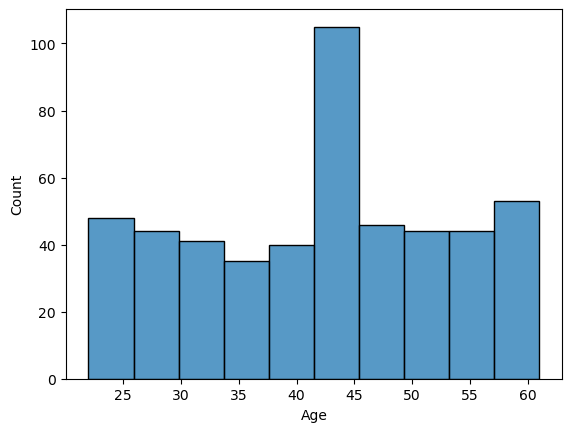

In [68]:
## Age Distribution
sns.histplot(df['Age'], bins=10)
plt.show()

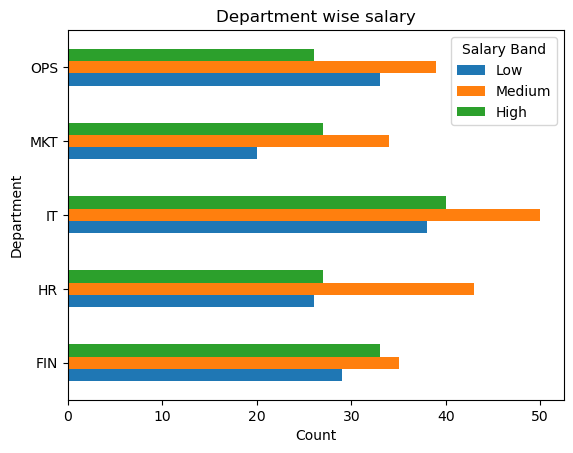

In [71]:
df1 = df.groupby('dept_code')['Salary_Band'].value_counts().unstack().fillna(0)
df1.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Department')
plt.title('Department wise salary')
plt.legend(title='Salary Band', loc='upper right')
plt.show()

In [ ]:
df1 = df['City'].value_counts()
plt.pie(df1, labels=df1.index, autopct='%1.1f%%')
plt.title('Percentage of JobRole')
plt.show()

In [ ]:
# 3. Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df3 = sns.lmplot(data = df, x = 'Years_Exp', y = 'salary_USD' , fit_reg = True , hue = 'dept_code' )

In [ ]:
df3 = sns.lmplot(data = df, x = 'Years_Exp', y = 'salary_USD' , fit_reg = True , hue = 'City' )

In [77]:
df.to_csv(r'C:\Users\shyam\OneDrive\Desktop\Imagine XP\Even\MBA-BA(2 SEM)\output.csv', index=False)